## O que é o Indicador Criança Alfabetizada

Links / referências<br/>
https://www.gov.br/mec/pt-br (política educacional)<br/>
Dados: camada **Gold** do datalake da Fase 2 — `gold/br_inep_alfabetizacao/`

O Indicador Criança Alfabetizada acompanha se crianças em idade escolar atingem o nível esperado de alfabetização. Na Fase 3 usamos a Gold já integrada (aluno, território, metas e contexto socioeconômico) para **prever** se um aluno será considerado alfabetizado (`alfabetizado` = 0 ou 1) e gerar inteligência para gestores públicos.

Trabalhamos com quatro tabelas Gold:
- **`alunos_features`** — fato por aluno (target da modelagem)
- **`contexto_territorio`** — município × rede (PIB, IVS, lags)
- **`indicador_crianca_alfabetizada_municipio`** — taxas e metas municipais
- **`indicador_crianca_alfabetizada_uf`** — taxas e metas por UF


**Pergunta Norteadora:**  
*"Quais fatores educacionais, territoriais e socioeconômicos estão associados à alfabetização do aluno, e como isso apoia a escolha de features e o cuidado com data leakage na modelagem?"

In [ ]:
# Libs
from pathlib import Path
import importlib
import sys
import warnings

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
sns.set_style("darkgrid")

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Recarrega módulos após alterações no código (evita cache do kernel)
for mod in ("src.config", "src.visualization.eda", "src.preprocessing.load_s3"):
    if mod in sys.modules:
        importlib.reload(sys.modules[mod])

import src.config as config
importlib.reload(config)

from src.config import DATALAKE_BUCKET, EDA_N_ROWS, GOLD_PREFIX, GOLD_YEAR, IMAGES_DIR, LEAKAGE_COLS, TARGET_COL
from src.visualization.eda import (
    build_eda_frame,
    correlation_with_target,
    feature_columns,
    load_eda_data,
    profile,
    split_feature_types,
    target_balance,
    write_eda_report,
)

pd.set_option("display.max_columns", 40)
IMAGES_DIR.mkdir(parents=True, exist_ok=True)
print(f"Fonte: s3://{DATALAKE_BUCKET}/{GOLD_PREFIX} | ano={GOLD_YEAR} | n_alunos={EDA_N_ROWS}")


Fonte: s3://tech-challenge-2-datalake-prod/gold/br_inep_alfabetizacao | ano=2023 | n_alunos=5000


### Leitura da base (Gold no S3)

Leitura **sempre** do datalake AWS:

`s3://{DATALAKE_BUCKET}/gold/br_inep_alfabetizacao/{tabela}/ano={GOLD_YEAR}/`

- **`alunos_features`:** `EDA_N_ROWS` linhas **sorteadas aleatoriamente** entre row groups (seed fixa, cache em data/processed/)
- **Demais tabelas:** partição completa do ano (são pequenas)

Credenciais AWS no `.env` (`AWS_ACCESS_KEY_ID`, `AWS_SECRET_ACCESS_KEY`, região).


In [2]:
tables = load_eda_data()
alunos = tables["alunos_features"]
contexto = tables["contexto_territorio"]
ind_mun = tables["indicador_crianca_alfabetizada_municipio"]
ind_uf = tables["indicador_crianca_alfabetizada_uf"]

alunos.head()

,id_aluno,id_municipio,rede,serie,alfabetizado,peso_aluno,_ingestion_timestamp,_silver_processed_at,_silver_batch_id,meta_alfabetizacao_2024,meta_alfabetizacao_2025,meta_alfabetizacao_2026,meta_alfabetizacao_2027,meta_alfabetizacao_2028,meta_alfabetizacao_2029,meta_alfabetizacao_2030,nivel_alfabetizacao,_source_table,_batch_id,nome_municipio,...,lag1_proporcao_aluno_nivel_2,lag1_proporcao_aluno_nivel_3,lag1_proporcao_aluno_nivel_4,lag1_proporcao_aluno_nivel_5,lag1_proporcao_aluno_nivel_6,lag1_proporcao_aluno_nivel_7,lag1_proporcao_aluno_nivel_8,lag1_uf_taxa_alfabetizacao,lag1_uf_media_portugues,lag1_uf_proporcao_aluno_nivel_0,lag1_uf_proporcao_aluno_nivel_1,lag1_uf_proporcao_aluno_nivel_2,lag1_uf_proporcao_aluno_nivel_3,lag1_uf_proporcao_aluno_nivel_4,lag1_uf_proporcao_aluno_nivel_5,lag1_uf_proporcao_aluno_nivel_6,lag1_uf_proporcao_aluno_nivel_7,lag1_uf_proporcao_aluno_nivel_8,_gold_processed_at,_gold_batch_id
0,22013361,2211001,municipal,2,0.0,NaN,2026-08-21T14:53:54.662279+00:00,2026-09-01T22:43:25.497453+00:00,09680cbf-1ca4-4aa0-aad4-93f80d0fc395,53.41,58.54,63.49,68.17,72.51,76.46,80.0,1.0,basedosdados.br_inep_avaliacao_alfabetizacao.m...,639d5481-b968-4c35-b649-4a48b1d0da10,Teresina,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-09-01T22:45:01.742065+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d
1,32014835,3205200,municipal,2,0.0,NaN,2026-08-21T14:53:54.662279+00:00,2026-09-01T22:43:25.497453+00:00,09680cbf-1ca4-4aa0-aad4-93f80d0fc395,70.00,71.85,73.63,75.34,76.97,78.52,80.0,3.0,basedosdados.br_inep_avaliacao_alfabetizacao.m...,639d5481-b968-4c35-b649-4a48b1d0da10,Vila Velha,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-09-01T22:45:01.742065+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d
2,21067617,2108058,municipal,2,1.0,1.100000,2026-08-21T14:53:54.662279+00:00,2026-09-01T22:43:25.497453+00:00,09680cbf-1ca4-4aa0-aad4-93f80d0fc395,67.34,69.72,72.00,74.17,76.23,78.17,80.0,3.0,basedosdados.br_inep_avaliacao_alfabetizacao.m...,639d5481-b968-4c35-b649-4a48b1d0da10,Paulino Neves,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-09-01T22:45:01.742065+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d
3,23066615,2313500,municipal,2,1.0,1.095238,2026-08-21T14:53:54.662279+00:00,2026-09-01T22:43:25.497453+00:00,09680cbf-1ca4-4aa0-aad4-93f80d0fc395,80.00,80.00,80.00,80.00,80.00,80.00,80.0,5.0,basedosdados.br_inep_avaliacao_alfabetizacao.m...,639d5481-b968-4c35-b649-4a48b1d0da10,Trairi,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-09-01T22:45:01.742065+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d
4,23004993,2304400,municipal,2,1.0,1.095300,2026-08-21T14:53:54.662279+00:00,2026-09-01T22:43:25.497453+00:00,09680cbf-1ca4-4aa0-aad4-93f80d0fc395,74.95,75.85,76.72,77.58,78.41,79.21,80.0,4.0,basedosdados.br_inep_avaliacao_alfabetizacao.m...,639d5481-b968-4c35-b649-4a48b1d0da10,Fortaleza,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-09-01T22:45:01.742065+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d


Tamanho da Base de Dados

In [3]:
print(f"alunos_features (Linhas, Colunas): {alunos.shape}")
print(f"contexto_territorio (Linhas, Colunas): {contexto.shape}")
print(f"indicador município (Linhas, Colunas): {ind_mun.shape}")
print(f"indicador UF (Linhas, Colunas): {ind_uf.shape}")

alunos_features (Linhas, Colunas): (5000, 79)
contexto_territorio (Linhas, Colunas): (6559, 81)
indicador município (Linhas, Colunas): (5888, 44)
indicador UF (Linhas, Colunas): (44, 37)


Verificar os tipos dos Dados

In [4]:
alunos.dtypes

id_aluno                               str
id_municipio                           str
rede                                   str
serie                                  str
alfabetizado                       float64
                                    ...   
lag1_uf_proporcao_aluno_nivel_6    float64
lag1_uf_proporcao_aluno_nivel_7    float64
lag1_uf_proporcao_aluno_nivel_8    float64
_gold_processed_at                     str
_gold_batch_id                         str
Length: 79, dtype: object

Existe valores nulos?

In [5]:
nulos = alunos.isnull().sum().sum()
print(f"Nulos em alunos_features (antes do join): {nulos}")

prof = profile(alunos)
prof.head(15)

Nulos em alunos_features (antes do join): 120122


,column,dtype,non_null,pct_missing,n_unique
72,lag1_uf_proporcao_aluno_nivel_4,float64,0,100.0,0
73,lag1_uf_proporcao_aluno_nivel_5,float64,0,100.0,0
74,lag1_uf_proporcao_aluno_nivel_6,float64,0,100.0,0
75,lag1_uf_proporcao_aluno_nivel_7,float64,0,100.0,0
76,lag1_uf_proporcao_aluno_nivel_8,float64,0,100.0,0
56,lag1_media_portugues,float64,0,100.0,0
55,lag1_taxa_alfabetizacao,float64,0,100.0,0
70,lag1_uf_proporcao_aluno_nivel_2,float64,0,100.0,0
69,lag1_uf_proporcao_aluno_nivel_1,float64,0,100.0,0
68,lag1_uf_proporcao_aluno_nivel_0,float64,0,100.0,0


> A Gold (Fase 2) deve entregar **fato + contexto já integrados** (`alunos_features` ou `alunos_analytic`). A Fase 3 apenas consome — sem join/normalização de `rede` ou chaves aqui.

Quais informações queremos trabalhar?

Selecionamos o target, chaves de junção e um conjunto enxuto de features de contexto (sem leakage).

In [6]:
print("Colunas alunos_features:")
print(list(alunos.columns))

print("\nColunas que NÃO entram no modelo (leakage / IDs / metadados):")
print([c for c in LEAKAGE_COLS if c in alunos.columns])

Colunas alunos_features:
['id_aluno', 'id_municipio', 'rede', 'serie', 'alfabetizado', 'peso_aluno', '_ingestion_timestamp', '_silver_processed_at', '_silver_batch_id', 'meta_alfabetizacao_2024', 'meta_alfabetizacao_2025', 'meta_alfabetizacao_2026', 'meta_alfabetizacao_2027', 'meta_alfabetizacao_2028', 'meta_alfabetizacao_2029', 'meta_alfabetizacao_2030', 'nivel_alfabetizacao', '_source_table', '_batch_id', 'nome_municipio', 'sigla_uf', 'nome_uf', 'regiao_municipio', 'capital_uf', 'nome_mesorregiao', 'nome_microrregiao', 'amazonia_legal', '_join_match', 'nome_regiao', 'uf_meta_alfabetizacao_2024', 'uf_meta_alfabetizacao_2025', 'uf_meta_alfabetizacao_2026', 'uf_meta_alfabetizacao_2027', 'uf_meta_alfabetizacao_2028', 'uf_meta_alfabetizacao_2029', 'uf_meta_alfabetizacao_2030', 'uf_nome_uf', 'uf_regiao_uf', 'brasil_meta_alfabetizacao_2024', 'brasil_meta_alfabetizacao_2025', 'brasil_meta_alfabetizacao_2026', 'brasil_meta_alfabetizacao_2027', 'brasil_meta_alfabetizacao_2028', 'brasil_meta_al

In [7]:
from src.config import GOLD_TABLE

# Tabela de modelagem — enriquecida na Gold (sem join manual)
df = build_eda_frame(tables)

if "sigla_uf" in df.columns:
    filled = df["sigla_uf"].notna().sum()
    print(f"Tabela `{GOLD_TABLE}`: {df.shape}")
    print(f"Linhas com sigla_uf: {filled} / {len(df)}")

df.head()

Tabela `alunos_features`: (5000, 57)
Linhas com sigla_uf: 5000 / 5000


,id_aluno,id_municipio,rede,serie,alfabetizado,peso_aluno,_ingestion_timestamp,_silver_processed_at,_silver_batch_id,meta_alfabetizacao_2024,meta_alfabetizacao_2025,meta_alfabetizacao_2026,meta_alfabetizacao_2027,meta_alfabetizacao_2028,meta_alfabetizacao_2029,meta_alfabetizacao_2030,nivel_alfabetizacao,_source_table,_batch_id,nome_municipio,...,uf_regiao_uf,brasil_meta_alfabetizacao_2024,brasil_meta_alfabetizacao_2025,brasil_meta_alfabetizacao_2026,brasil_meta_alfabetizacao_2027,brasil_meta_alfabetizacao_2028,brasil_meta_alfabetizacao_2029,brasil_meta_alfabetizacao_2030,populacao,populacao_ano_ref,pib,pib_ano_ref,pib_per_capita,socio_ano_ref,ivs,ivs_infraestrutura_urbana,ivs_capital_humano,ivs_renda_trabalho,_gold_processed_at,_gold_batch_id
0,22013361,2211001,municipal,2,0.0,NaN,2026-08-21T14:53:54.662279+00:00,2026-09-01T22:43:25.497453+00:00,09680cbf-1ca4-4aa0-aad4-93f80d0fc395,53.41,58.54,63.49,68.17,72.51,76.46,80.0,1.0,basedosdados.br_inep_avaliacao_alfabetizacao.m...,639d5481-b968-4c35-b649-4a48b1d0da10,Teresina,...,Nordeste,59.9,63.77,67.47,70.97,74.23,77.24,80.0,866300,2023,29449063000,2023,33994.070184,2010.0,0.285,0.207,0.312,0.335,2026-09-01T22:45:01.742065+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d
1,32014835,3205200,municipal,2,0.0,NaN,2026-08-21T14:53:54.662279+00:00,2026-09-01T22:43:25.497453+00:00,09680cbf-1ca4-4aa0-aad4-93f80d0fc395,70.00,71.85,73.63,75.34,76.97,78.52,80.0,3.0,basedosdados.br_inep_avaliacao_alfabetizacao.m...,639d5481-b968-4c35-b649-4a48b1d0da10,Vila Velha,...,Sudeste,59.9,63.77,67.47,70.97,74.23,77.24,80.0,467722,2023,19711328000,2023,42143.256037,2010.0,0.260,0.230,0.300,0.249,2026-09-01T22:45:01.742065+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d
2,21067617,2108058,municipal,2,1.0,1.100000,2026-08-21T14:53:54.662279+00:00,2026-09-01T22:43:25.497453+00:00,09680cbf-1ca4-4aa0-aad4-93f80d0fc395,67.34,69.72,72.00,74.17,76.23,78.17,80.0,3.0,basedosdados.br_inep_avaliacao_alfabetizacao.m...,639d5481-b968-4c35-b649-4a48b1d0da10,Paulino Neves,...,Nordeste,59.9,63.77,67.47,70.97,74.23,77.24,80.0,17056,2023,157984000,2023,9262.664165,2010.0,NaN,NaN,0.601,0.717,2026-09-01T22:45:01.742065+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d
3,23066615,2313500,municipal,2,1.0,1.095238,2026-08-21T14:53:54.662279+00:00,2026-09-01T22:43:25.497453+00:00,09680cbf-1ca4-4aa0-aad4-93f80d0fc395,80.00,80.00,80.00,80.00,80.00,80.00,80.0,5.0,basedosdados.br_inep_avaliacao_alfabetizacao.m...,639d5481-b968-4c35-b649-4a48b1d0da10,Trairi,...,Nordeste,59.9,63.77,67.47,70.97,74.23,77.24,80.0,58415,2023,1039083000,2023,17787.948301,2010.0,NaN,NaN,0.558,0.607,2026-09-01T22:45:01.742065+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d
4,23004993,2304400,municipal,2,1.0,1.095300,2026-08-21T14:53:54.662279+00:00,2026-09-01T22:43:25.497453+00:00,09680cbf-1ca4-4aa0-aad4-93f80d0fc395,74.95,75.85,76.72,77.58,78.41,79.21,80.0,4.0,basedosdados.br_inep_avaliacao_alfabetizacao.m...,639d5481-b968-4c35-b649-4a48b1d0da10,Fortaleza,...,Nordeste,59.9,63.77,67.47,70.97,74.23,77.24,80.0,2428708,2023,86939832000,2023,35796.741313,2010.0,0.194,0.145,0.221,0.217,2026-09-01T22:45:01.742065+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d


In [8]:
df.tail()

,id_aluno,id_municipio,rede,serie,alfabetizado,peso_aluno,_ingestion_timestamp,_silver_processed_at,_silver_batch_id,meta_alfabetizacao_2024,meta_alfabetizacao_2025,meta_alfabetizacao_2026,meta_alfabetizacao_2027,meta_alfabetizacao_2028,meta_alfabetizacao_2029,meta_alfabetizacao_2030,nivel_alfabetizacao,_source_table,_batch_id,nome_municipio,...,uf_regiao_uf,brasil_meta_alfabetizacao_2024,brasil_meta_alfabetizacao_2025,brasil_meta_alfabetizacao_2026,brasil_meta_alfabetizacao_2027,brasil_meta_alfabetizacao_2028,brasil_meta_alfabetizacao_2029,brasil_meta_alfabetizacao_2030,populacao,populacao_ano_ref,pib,pib_ano_ref,pib_per_capita,socio_ano_ref,ivs,ivs_infraestrutura_urbana,ivs_capital_humano,ivs_renda_trabalho,_gold_processed_at,_gold_batch_id
4995,27001110,2700102,municipal,2,0.0,1.0,2026-08-21T14:53:54.662279+00:00,2026-09-01T22:43:25.497453+00:00,09680cbf-1ca4-4aa0-aad4-93f80d0fc395,52.49,57.79,62.92,67.77,72.26,76.35,80.0,1.0,basedosdados.br_inep_avaliacao_alfabetizacao.m...,639d5481-b968-4c35-b649-4a48b1d0da10,Água Branca,...,Nordeste,59.9,63.77,67.47,70.97,74.23,77.24,80.0,19174,2023,246052000,2023,12832.585793,2010.0,NaN,NaN,NaN,0.705,2026-09-01T22:45:01.742065+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d
4996,31043532,3103009,municipal,2,1.0,1.0,2026-08-21T14:53:54.662279+00:00,2026-09-01T22:43:25.497453+00:00,09680cbf-1ca4-4aa0-aad4-93f80d0fc395,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Antônio Dias,...,Sudeste,59.9,63.77,67.47,70.97,74.23,77.24,80.0,9219,2023,535451000,2023,58081.245254,2010.0,0.367,0.270,0.423,0.408,2026-09-01T22:45:01.742065+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d
4997,23024889,2304285,municipal,2,1.0,1.0,2026-08-21T14:53:54.662279+00:00,2026-09-01T22:43:25.497453+00:00,09680cbf-1ca4-4aa0-aad4-93f80d0fc395,80.00,80.00,80.00,80.00,80.00,80.00,80.0,5.0,basedosdados.br_inep_avaliacao_alfabetizacao.m...,639d5481-b968-4c35-b649-4a48b1d0da10,Eusébio,...,Nordeste,59.9,63.77,67.47,70.97,74.23,77.24,80.0,74170,2023,4940352000,2023,66608.494000,2010.0,0.417,0.311,0.505,0.435,2026-09-01T22:45:01.742065+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d
4998,28090948,2807105,municipal,2,0.0,1.0,2026-08-21T14:53:54.662279+00:00,2026-09-01T22:43:25.497453+00:00,09680cbf-1ca4-4aa0-aad4-93f80d0fc395,40.09,47.41,54.84,62.07,68.79,74.81,80.0,0.0,basedosdados.br_inep_avaliacao_alfabetizacao.m...,639d5481-b968-4c35-b649-4a48b1d0da10,Simão Dias,...,Nordeste,59.9,63.77,67.47,70.97,74.23,77.24,80.0,42578,2023,925387000,2023,21733.923623,2010.0,0.403,0.189,0.439,0.582,2026-09-01T22:45:01.742065+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d
4999,26050274,2611606,municipal,2,0.0,1.0,2026-08-21T14:53:54.662279+00:00,2026-09-01T22:43:25.497453+00:00,09680cbf-1ca4-4aa0-aad4-93f80d0fc395,65.29,68.08,70.75,73.28,75.67,77.91,80.0,3.0,basedosdados.br_inep_avaliacao_alfabetizacao.m...,639d5481-b968-4c35-b649-4a48b1d0da10,Recife,...,Nordeste,59.9,63.77,67.47,70.97,74.23,77.24,80.0,1488920,2023,66351305000,2023,44563.378153,2010.0,0.274,0.310,0.253,0.260,2026-09-01T22:45:01.742065+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d


Informações da Base (após o enriquecimento)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 57 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id_aluno                        5000 non-null   str    
 1   id_municipio                    5000 non-null   str    
 2   rede                            5000 non-null   str    
 3   serie                           5000 non-null   str    
 4   alfabetizado                    5000 non-null   float64
 5   peso_aluno                      4313 non-null   float64
 6   _ingestion_timestamp            5000 non-null   str    
 7   _silver_processed_at            5000 non-null   str    
 8   _silver_batch_id                5000 non-null   str    
 9   meta_alfabetizacao_2024         4349 non-null   float64
 10  meta_alfabetizacao_2025         4396 non-null   float64
 11  meta_alfabetizacao_2026         4396 non-null   float64
 12  meta_alfabetizacao_2027         4396 non-null

Valores únicos

In [10]:
df.nunique()

id_aluno                          5000
id_municipio                      1745
rede                                 2
serie                                1
alfabetizado                         2
peso_aluno                        3233
_ingestion_timestamp                 1
_silver_processed_at                 1
_silver_batch_id                     1
meta_alfabetizacao_2024           1172
meta_alfabetizacao_2025           1123
meta_alfabetizacao_2026           1108
meta_alfabetizacao_2027           1019
meta_alfabetizacao_2028            876
meta_alfabetizacao_2029            582
meta_alfabetizacao_2030              1
nivel_alfabetizacao                  6
_source_table                        1
_batch_id                            1
nome_municipio                    1717
sigla_uf                            23
nome_uf                             23
regiao_municipio                     5
capital_uf                           2
nome_mesorregiao                   117
nome_microrregiao        

Estatística Descritiva

In [11]:
df.describe().round(2)

,alfabetizado,peso_aluno,meta_alfabetizacao_2024,meta_alfabetizacao_2025,meta_alfabetizacao_2026,meta_alfabetizacao_2027,meta_alfabetizacao_2028,meta_alfabetizacao_2029,meta_alfabetizacao_2030,nivel_alfabetizacao,capital_uf,amazonia_legal,uf_meta_alfabetizacao_2024,uf_meta_alfabetizacao_2025,uf_meta_alfabetizacao_2026,uf_meta_alfabetizacao_2027,uf_meta_alfabetizacao_2028,uf_meta_alfabetizacao_2029,uf_meta_alfabetizacao_2030,brasil_meta_alfabetizacao_2024,brasil_meta_alfabetizacao_2025,brasil_meta_alfabetizacao_2026,brasil_meta_alfabetizacao_2027,brasil_meta_alfabetizacao_2028,brasil_meta_alfabetizacao_2029,brasil_meta_alfabetizacao_2030,populacao,populacao_ano_ref,pib,pib_ano_ref,pib_per_capita,socio_ano_ref,ivs,ivs_infraestrutura_urbana,ivs_capital_humano,ivs_renda_trabalho
count,5000.00,4313.00,4349.00,4396.00,4396.00,4396.00,4396.00,4396.00,4396.0,4349.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.0,5000.0,5000.00,5000.00,5000.00,5000.00,5000.00,5000.0,5000.00,5000.0,5.000000e+03,5000.0,5000.00,4999.0,3760.00,4093.00,4461.00,4990.00
mean,0.51,1.15,60.62,64.08,67.69,71.16,74.40,77.35,80.0,2.27,0.17,0.19,61.04,64.65,68.14,71.46,74.56,77.42,80.0,59.9,63.77,67.47,70.97,74.23,77.24,80.0,532809.40,2023.0,3.063346e+10,2023.0,47860.27,2010.0,0.31,0.26,0.39,0.35
std,0.50,0.36,12.80,10.59,8.18,5.83,3.63,1.67,0.0,1.52,0.38,0.39,9.59,7.77,5.96,4.25,2.64,1.22,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.0,1212827.61,0.0,7.915271e+10,0.0,47521.98,0.0,0.11,0.17,0.14,0.15
min,0.00,0.18,16.94,25.09,35.49,47.46,59.73,70.90,80.0,0.00,0.00,0.00,38.30,45.90,53.60,61.20,68.30,74.60,80.0,59.9,63.77,67.47,70.97,74.23,77.24,80.0,924.00,2023.0,2.673800e+07,2023.0,7201.71,2010.0,0.06,0.00,0.11,0.08
25%,0.00,1.00,52.13,57.21,62.47,67.45,72.07,76.26,80.0,1.00,0.00,0.00,56.70,61.20,65.50,69.60,73.40,76.90,80.0,59.9,63.77,67.47,70.97,74.23,77.24,80.0,24711.25,2023.0,6.890190e+08,2023.0,22782.93,2010.0,0.22,0.12,0.29,0.22
50%,1.00,1.08,60.63,64.21,67.80,71.20,74.37,77.31,80.0,2.00,0.00,0.00,62.40,65.80,69.00,72.10,74.90,77.60,80.0,59.9,63.77,67.47,70.97,74.23,77.24,80.0,85597.50,2023.0,3.631624e+09,2023.0,38322.06,2010.0,0.30,0.23,0.38,0.32
75%,1.00,1.21,70.55,72.21,73.91,75.54,77.10,78.58,80.0,3.00,0.00,0.00,66.20,68.80,71.30,73.70,75.90,78.00,80.0,59.9,63.77,67.47,70.97,74.23,77.24,80.0,370879.00,2023.0,1.990734e+10,2023.0,61855.15,2010.0,0.38,0.40,0.47,0.46
max,1.00,10.91,80.00,80.00,80.00,80.00,80.00,80.00,80.0,5.00,1.00,1.00,80.00,80.00,80.00,80.00,80.00,80.00,80.0,59.9,63.77,67.47,70.97,74.23,77.24,80.0,6211223.00,2023.0,4.184624e+11,2023.0,722441.52,2010.0,0.71,1.00,0.88,0.89


### Primeira análise — o target

**`alfabetizado`**
- `1` → aluno considerado alfabetizado  
- `0` → aluno não alfabetizado  

Essa é a variável que o modelo supervisionado deverá prever.

Distribuição do target:


,count,proportion
alfabetizado,,
1.0,2553,0.5106
0.0,2447,0.4894


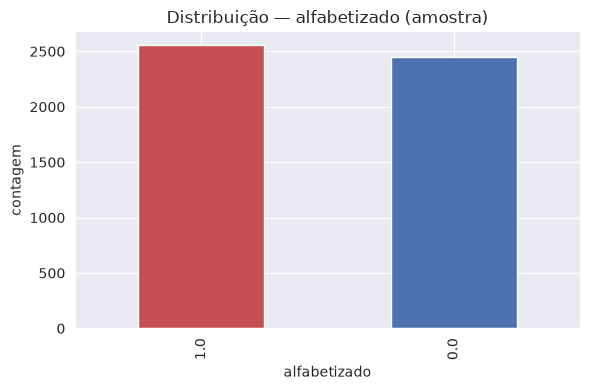

In [12]:
print("Distribuição do target:")
display(target_balance(df))

plt.figure(figsize=(6, 4))
df[TARGET_COL].value_counts(dropna=False).plot(kind="bar", color=["#c44e52", "#4c72b0"])
plt.title("Distribuição — alfabetizado (amostra)")
plt.xlabel(TARGET_COL)
plt.ylabel("contagem")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "eda_target_distribution.png", dpi=120)
plt.show()

Interessante observar se a amostra está equilibrada. Se uma classe dominar demais, na modelagem priorizamos métricas como **F1 / recall** e, se preciso, `class_weight`.

### Análise por rede e território

Pergunta: a taxa média de alfabetização na amostra muda entre redes e regiões?

,taxa_media_alfabetizado
rede,
estadual,0.525641
municipal,0.509047


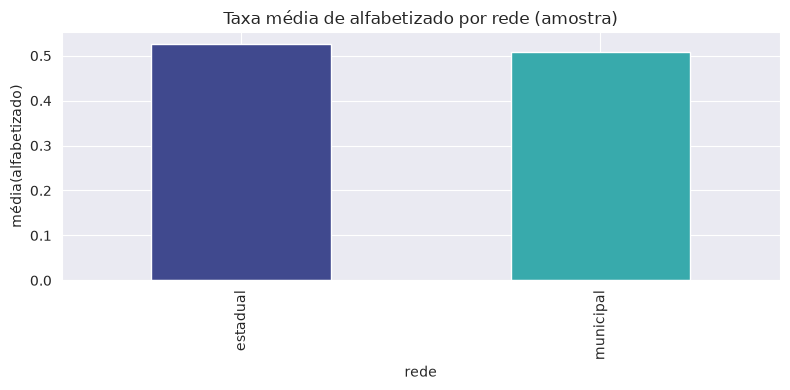

In [13]:
if "rede" in df.columns:
    taxa_rede = df.groupby("rede")[TARGET_COL].mean().sort_values(ascending=False)
    display(taxa_rede.to_frame("taxa_media_alfabetizado"))

    plt.figure(figsize=(8, 4))
    taxa_rede.plot(kind="bar", color=sns.color_palette("mako", len(taxa_rede)))
    plt.title("Taxa média de alfabetizado por rede (amostra)")
    plt.ylabel(f"média({TARGET_COL})")
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / "eda_rede_vs_target.png", dpi=120)
    plt.show()

,taxa_media_alfabetizado
nome_regiao,
Sul,0.577452
Centro-Oeste,0.541284
Sudeste,0.506515
Nordeste,0.492465
Norte,0.423208


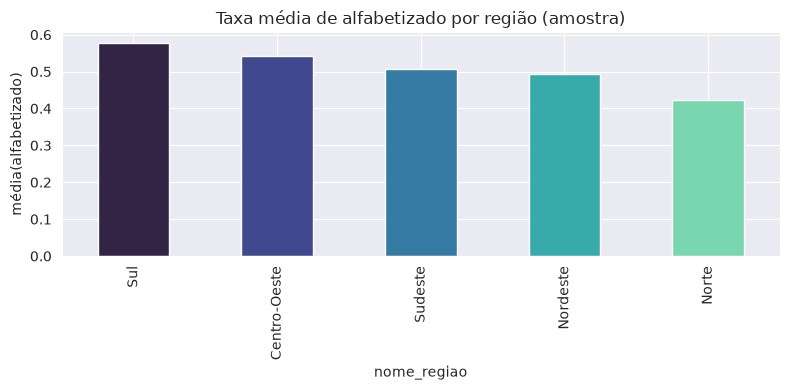

In [14]:
if "nome_regiao" in df.columns and df["nome_regiao"].notna().any():
    taxa_regiao = df.groupby("nome_regiao")[TARGET_COL].mean().sort_values(ascending=False)
    display(taxa_regiao.to_frame("taxa_media_alfabetizado"))

    plt.figure(figsize=(8, 4))
    taxa_regiao.plot(kind="bar", color=sns.color_palette("mako", len(taxa_regiao)))
    plt.title("Taxa média de alfabetizado por região (amostra)")
    plt.ylabel(f"média({TARGET_COL})")
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / "eda_nome_regiao_vs_target.png", dpi=120)
    plt.show()
else:
    print("nome_regiao sem valores preenchidos após o merge nesta amostra.")

Se houver diferença clara entre redes/regiões, isso reforça a hipótese de que **variáveis territoriais** devem entrar no modelo (com encoding categórico).

### Distribuições numéricas

Olhamos PIB per capita, IVS e lags — candidatas fortes a features.

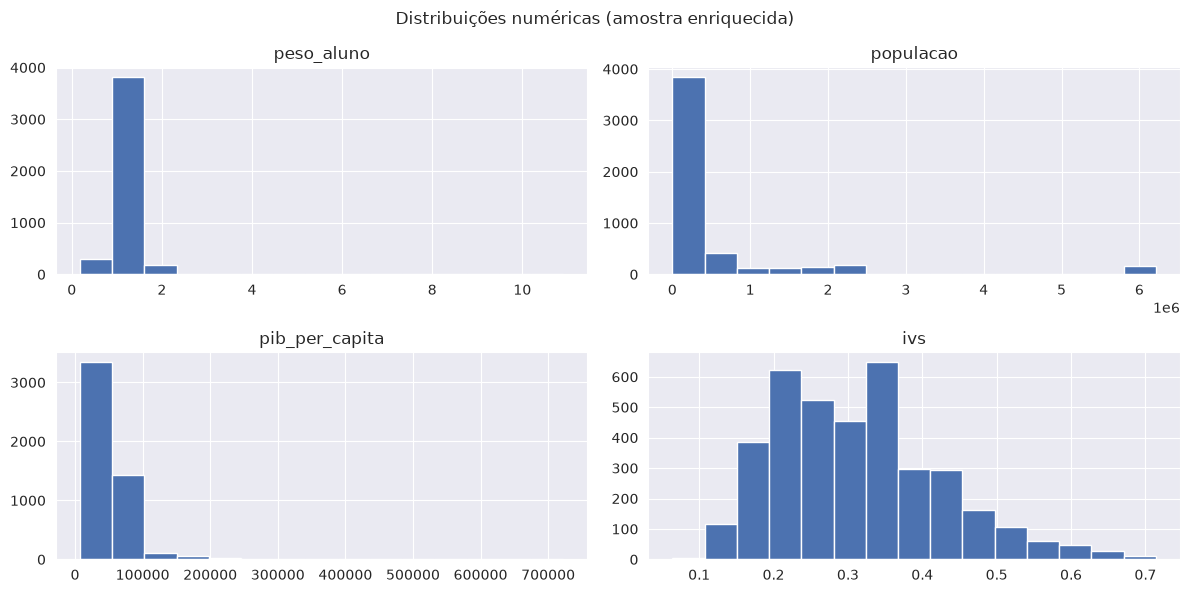

In [15]:
num_plot = [
    c
    for c in ["peso_aluno", "populacao", "pib_per_capita", "ivs", "lag1_taxa_alfabetizacao"]
    if c in df.columns and df[c].notna().any()
]

if num_plot:
    df[num_plot].hist(bins=15, figsize=(12, 6), color="#4c72b0", edgecolor="white")
    plt.suptitle("Distribuições numéricas (amostra enriquecida)")
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / "eda_numeric_distributions.png", dpi=120)
    plt.show()
else:
    print("Sem colunas numéricas preenchidas para histograma nesta amostra.")

### Pairplot / relações

Aqui buscamos relações entre contexto socioeconômico e o target.

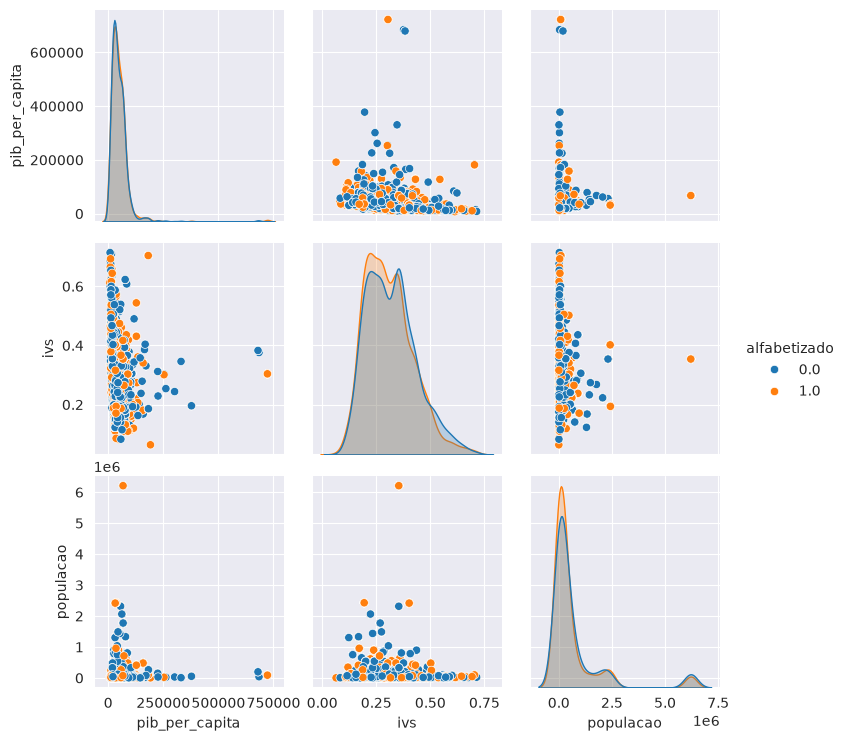

In [16]:
pair_cols = [
    c
    for c in [TARGET_COL, "pib_per_capita", "ivs", "lag1_taxa_alfabetizacao", "populacao"]
    if c in df.columns and df[c].notna().any()
]

if len(pair_cols) >= 3:
    sns.pairplot(df[pair_cols].dropna(), hue=TARGET_COL if TARGET_COL in pair_cols else None)
    plt.show()
else:
    print("Amostra insuficiente de colunas preenchidas para pairplot.")

Interessante observar se `ivs` / `pib_per_capita` / `lag1_taxa_alfabetizacao` se separam visualmente entre alfabetizados e não alfabetizados. Isso guia a priorização de features.

### Correlações

Matriz de correlação entre variáveis numéricas relevantes e o target (amostra — provisória).

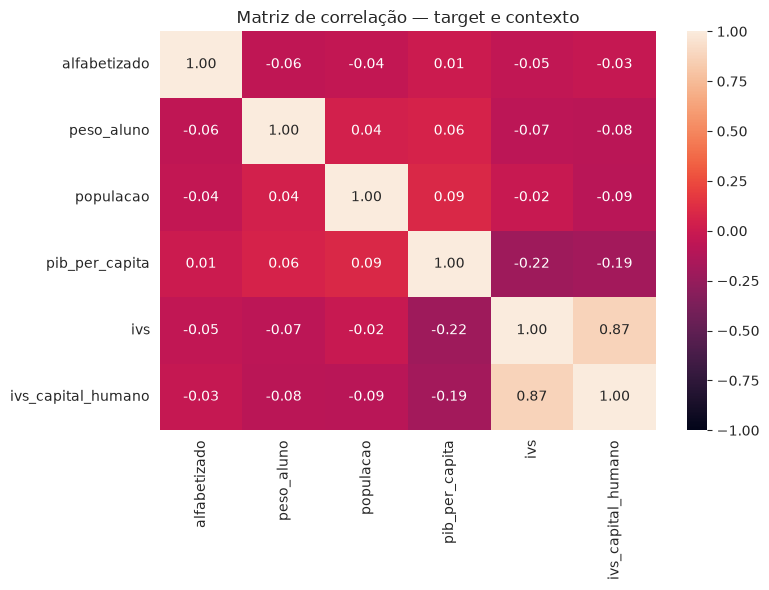

Correlação com o target (amostra):


meta_alfabetizacao_2029       0.311705
meta_alfabetizacao_2028       0.310421
meta_alfabetizacao_2024       0.310076
meta_alfabetizacao_2027       0.309466
meta_alfabetizacao_2025       0.309026
meta_alfabetizacao_2026       0.308991
nivel_alfabetizacao           0.301580
uf_meta_alfabetizacao_2029    0.245073
uf_meta_alfabetizacao_2028    0.244796
uf_meta_alfabetizacao_2027    0.244262
uf_meta_alfabetizacao_2026    0.243997
uf_meta_alfabetizacao_2025    0.243800
uf_meta_alfabetizacao_2024    0.243749
ivs_infraestrutura_urbana    -0.073475
peso_aluno                   -0.058808
Name: alfabetizado, dtype: float64

In [17]:
cols_corr = [
    c
    for c in [
        TARGET_COL,
        "peso_aluno",
        "populacao",
        "pib_per_capita",
        "ivs",
        "ivs_capital_humano",
        "lag1_taxa_alfabetizacao",
    ]
    if c in df.columns and df[c].notna().any()
]

if len(cols_corr) >= 2:
    corr = df[cols_corr].corr(numeric_only=True)
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="rocket", vmin=-1, vmax=1)
    plt.title("Matriz de correlação — target e contexto")
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / "eda_correlation_heatmap.png", dpi=120)
    plt.show()

    print("Correlação com o target (amostra):")
    display(correlation_with_target(df))
else:
    print("Poucas colunas numéricas preenchidas para correlação nesta amostra.")

### Indicadores agregados (município e UF)

Essas bases respondem perguntas de **negócio** (metas, risco municipal), não o grain do classificador de aluno.

Indicador município — preview


,id_municipio,rede,total_alunos,total_peso,total_alfabetizados_ponderado,proficiencia_media_ponderada,taxa_crianca_alfabetizada,taxa_alfabetizacao,meta_alfabetizacao_2024,meta_alfabetizacao_2025,meta_alfabetizacao_2026,meta_alfabetizacao_2027,meta_alfabetizacao_2028,meta_alfabetizacao_2029,meta_alfabetizacao_2030,nome_municipio,nome_uf,sigla_uf,percentual_participacao,regiao_municipio,...,gap_taxa_vs_inep,gap_meta_2024,gap_meta_2025,gap_meta_2026,gap_meta_2027,gap_meta_2028,gap_meta_2029,gap_meta_2030,nome_regiao,brasil_taxa_alfabetizacao,brasil_meta_alfabetizacao_2024,brasil_meta_alfabetizacao_2025,brasil_meta_alfabetizacao_2026,brasil_meta_alfabetizacao_2027,brasil_meta_alfabetizacao_2028,brasil_meta_alfabetizacao_2029,brasil_meta_alfabetizacao_2030,brasil_percentual_participacao,_gold_processed_at,_gold_batch_id
0,1100015,municipal,254.0,280.999998,163.949817,685.465931,58.345131,64.6,67.08,69.51,71.84,74.06,76.16,78.14,80.0,Alta Floresta D'Oeste,Rondônia,RO,89.37,Norte,...,-6.254869,-8.734869,-11.164869,-13.494869,-15.714869,-17.814869,-19.794869,-21.654869,Norte,55.9,59.9,63.77,67.47,70.97,74.23,77.24,80.0,86.0,2026-09-01T22:44:22.267804+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d
1,1100023,municipal,1361.0,1500.779170,848.363548,686.977175,56.528206,62.3,65.22,68.02,70.71,73.25,75.65,77.90,80.0,Ariquemes,Rondônia,RO,89.79,Norte,...,-5.771794,-8.691794,-11.491794,-14.181794,-16.721794,-19.121794,-21.371794,-23.471794,Norte,55.9,59.9,63.77,67.47,70.97,74.23,77.24,80.0,86.0,2026-09-01T22:44:22.267804+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d
2,1100031,municipal,84.0,92.000000,58.043590,701.104461,63.090859,69.1,70.85,72.53,74.15,75.71,77.21,78.64,80.0,Cabixi,Rondônia,RO,90.48,Norte,...,-6.009141,-7.759141,-9.439141,-11.059141,-12.619141,-14.119141,-15.549141,-16.909141,Norte,55.9,59.9,63.77,67.47,70.97,74.23,77.24,80.0,86.0,2026-09-01T22:44:22.267804+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d


,count,mean,std,min,25%,50%,75%,max
total_alunos,5888.0,296.78,1108.48,8.00,47.00,102.00,242.00,54533.00
total_peso,5888.0,337.68,1303.17,8.00,52.02,112.73,266.00,64208.00
total_alfabetizados_ponderado,5888.0,170.16,632.91,0.00,27.03,57.78,139.07,30644.62
proficiencia_media_ponderada,5888.0,678.61,61.89,0.00,644.56,682.54,715.99,868.46
taxa_crianca_alfabetizada,5888.0,55.24,19.94,0.00,40.80,55.57,70.08,100.00
taxa_alfabetizacao,4611.0,60.42,20.31,4.40,45.65,61.30,76.00,100.00
meta_alfabetizacao_2024,4611.0,62.02,15.60,7.94,51.20,64.38,76.60,80.00
meta_alfabetizacao_2025,4681.0,65.16,13.04,14.05,56.48,67.24,77.15,80.00
meta_alfabetizacao_2026,4681.0,68.49,10.18,23.65,61.91,70.11,77.75,80.00
meta_alfabetizacao_2027,4681.0,71.72,7.29,37.00,67.06,72.83,78.33,80.00


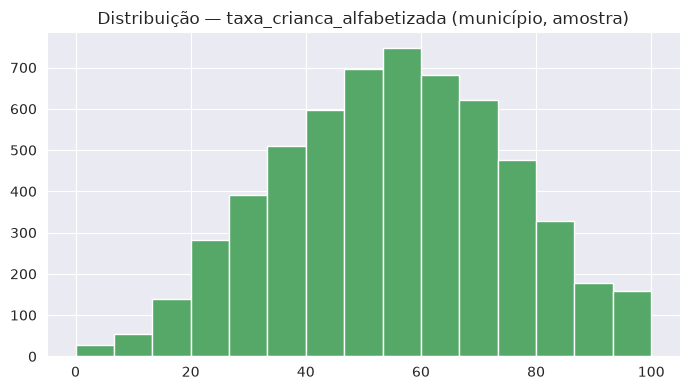

In [18]:
print("Indicador município — preview")
display(ind_mun.head(3))
display(ind_mun.describe().round(2).T.head(12))

if "taxa_crianca_alfabetizada" in ind_mun.columns:
    plt.figure(figsize=(7, 4))
    ind_mun["taxa_crianca_alfabetizada"].dropna().hist(bins=15, color="#55a868", edgecolor="white")
    plt.title("Distribuição — taxa_crianca_alfabetizada (município, amostra)")
    plt.tight_layout()
    plt.show()

Indicador UF — preview


,sigla_uf,rede,total_alunos,total_peso,total_alfabetizados_ponderado,proficiencia_media_ponderada,taxa_crianca_alfabetizada,taxa_alfabetizacao,meta_alfabetizacao_2024,meta_alfabetizacao_2025,meta_alfabetizacao_2026,meta_alfabetizacao_2027,meta_alfabetizacao_2028,meta_alfabetizacao_2029,meta_alfabetizacao_2030,nome_uf,percentual_participacao,regiao_uf,gap_taxa_vs_inep,gap_meta_2024,gap_meta_2025,gap_meta_2026,gap_meta_2027,gap_meta_2028,gap_meta_2029,gap_meta_2030,brasil_taxa_alfabetizacao,brasil_meta_alfabetizacao_2024,brasil_meta_alfabetizacao_2025,brasil_meta_alfabetizacao_2026,brasil_meta_alfabetizacao_2027,brasil_meta_alfabetizacao_2028,brasil_meta_alfabetizacao_2029,brasil_meta_alfabetizacao_2030,brasil_percentual_participacao,_gold_processed_at,_gold_batch_id
0,AL,estadual,1620.0,1806.000001,626.129678,650.152193,34.669417,43.88,49.7,55.5,61.1,66.5,71.5,76.0,80.0,Alagoas,92.36,Nordeste,-9.210583,-15.030583,-20.830583,-26.430583,-31.830583,-36.830583,-41.330583,-45.330583,55.9,59.9,63.77,67.47,70.97,74.23,77.24,80.0,86.0,2026-09-01T22:44:38.243234+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d
1,AL,municipal,33883.0,36410.999980,14954.019755,679.277380,41.070061,43.88,49.7,55.5,61.1,66.5,71.5,76.0,80.0,Alagoas,92.36,Nordeste,-2.809939,-8.629939,-14.429939,-20.029939,-25.429939,-30.429939,-34.929939,-38.929939,55.9,59.9,63.77,67.47,70.97,74.23,77.24,80.0,86.0,2026-09-01T22:44:38.243234+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d
2,AM,estadual,14102.0,16341.000023,8832.073443,643.962680,54.048549,52.20,56.8,61.3,65.6,69.6,73.4,76.9,80.0,Amazonas,76.14,Norte,1.848549,-2.751451,-7.251451,-11.551451,-15.551451,-19.351451,-22.851451,-25.951451,55.9,59.9,63.77,67.47,70.97,74.23,77.24,80.0,86.0,2026-09-01T22:44:38.243234+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d
3,AM,municipal,48953.0,61759.000014,24084.669003,581.535335,38.997829,52.20,56.8,61.3,65.6,69.6,73.4,76.9,80.0,Amazonas,76.14,Norte,-13.202171,-17.802171,-22.302171,-26.602171,-30.602171,-34.402171,-37.902171,-41.002171,55.9,59.9,63.77,67.47,70.97,74.23,77.24,80.0,86.0,2026-09-01T22:44:38.243234+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d
4,AP,estadual,3274.0,3689.000001,1332.501479,649.150992,36.120940,41.56,47.6,53.8,59.9,65.6,70.9,75.8,80.0,Amapá,89.68,Norte,-5.439060,-11.479060,-17.679060,-23.779060,-29.479060,-34.779060,-39.679060,-43.879060,55.9,59.9,63.77,67.47,70.97,74.23,77.24,80.0,86.0,2026-09-01T22:44:38.243234+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d


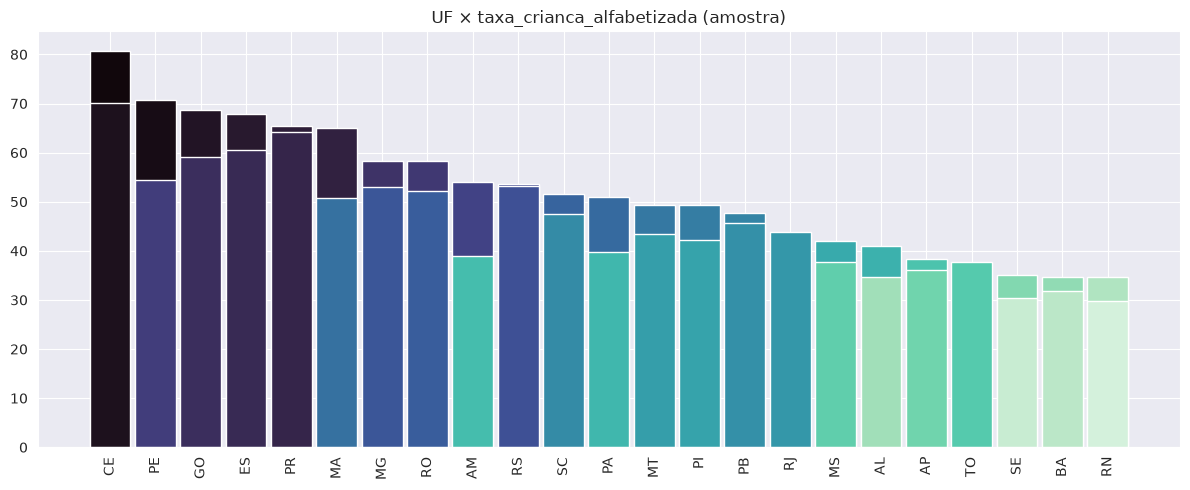

In [19]:
print("Indicador UF — preview")
display(ind_uf.head(5))

if {"sigla_uf", "taxa_crianca_alfabetizada"}.issubset(ind_uf.columns):
    tmp = ind_uf.dropna(subset=["taxa_crianca_alfabetizada"]).sort_values(
        "taxa_crianca_alfabetizada", ascending=False
    )
    plt.figure(figsize=(12, 5))
    pal = sns.color_palette("mako", len(tmp))
    plt.bar(tmp["sigla_uf"].astype(str), tmp["taxa_crianca_alfabetizada"], color=pal, width=0.9)
    plt.title("UF × taxa_crianca_alfabetizada (amostra)")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / "eda_uf_taxa.png", dpi=120)
    plt.show()

Esse tipo de visão por UF ajuda a responder: *quais estados/municípios apresentam maior risco educacional?* — pergunta estratégica do Tech Challenge.

### Features candidatas vs leakage

Resumo do que deve (e não deve) ir para a pipeline Scikit-learn.

In [20]:
feats = feature_columns(df)
num, cat = split_feature_types(df, feats)

print(f"Features candidatas: {len(feats)}")
print(f"Numéricas ({len(num)}):", num)
print(f"Categóricas ({len(cat)}):", cat)
print("\nExcluir do modelo:", [c for c in LEAKAGE_COLS if c in alunos.columns or c in df.columns])

Features candidatas: 47
Numéricas (35): ['peso_aluno', 'meta_alfabetizacao_2024', 'meta_alfabetizacao_2025', 'meta_alfabetizacao_2026', 'meta_alfabetizacao_2027', 'meta_alfabetizacao_2028', 'meta_alfabetizacao_2029', 'meta_alfabetizacao_2030', 'nivel_alfabetizacao', 'capital_uf', 'amazonia_legal', 'uf_meta_alfabetizacao_2024', 'uf_meta_alfabetizacao_2025', 'uf_meta_alfabetizacao_2026', 'uf_meta_alfabetizacao_2027', 'uf_meta_alfabetizacao_2028', 'uf_meta_alfabetizacao_2029', 'uf_meta_alfabetizacao_2030', 'brasil_meta_alfabetizacao_2024', 'brasil_meta_alfabetizacao_2025', 'brasil_meta_alfabetizacao_2026', 'brasil_meta_alfabetizacao_2027', 'brasil_meta_alfabetizacao_2028', 'brasil_meta_alfabetizacao_2029', 'brasil_meta_alfabetizacao_2030', 'populacao', 'populacao_ano_ref', 'pib', 'pib_ano_ref', 'pib_per_capita', 'socio_ano_ref', 'ivs', 'ivs_infraestrutura_urbana', 'ivs_capital_humano', 'ivs_renda_trabalho']
Categóricas (12): ['id_municipio', 'rede', 'serie', 'nome_municipio', 'sigla_uf', 

### Hipóteses analíticas

| # | Hipótese | Variáveis | Implicação para modelagem |
|---|----------|-----------|---------------------------|
| H1 | Contexto socioeconômico influencia a chance de alfabetização | `ivs*`, `pib_per_capita`, `populacao` | Incluir + imputar missing |
| H2 | Histórico municipal (lag) é preditivo com menor risco de leakage | `lag1_*` | Preferir lags a taxas do mesmo evento |
| H3 | Região e rede escolar alteram a taxa de alfabetização | `nome_regiao`, `sigla_uf`, `rede` | One-hot / encoding |
| H4 | Metas sozinhas não explicam o aluno | `meta_alfabetizacao_*` | Usar com cautela |

**Decisões de modelagem (a partir desta EDA):**
1. Grain = **aluno**; target = **`alfabetizado`**
2. Enriquecer fato aluno com `contexto_territorio` (`id_municipio`, `rede`)
3. Remover `id_aluno` e metadados `_silver_*` / `_gold_*`; usar `nivel_alfabetizacao` como feature se a Gold expuser
4. Pipeline: imputação + scaling (num) e imputação + one-hot (cat)
5. Revalidar em amostra maior / Gold S3 antes do treino final

**Amostragem e partição (revisão):** EDA e modelagem usam `ano=2024` com peek aleatório. `nivel_alfabetizacao` é municipal. Split de treino/teste deve ser agrupado por `id_municipio`.


In [21]:
images = sorted(IMAGES_DIR.glob("eda_*.png"))
report = write_eda_report(tables, images, enriched=df)
print("Relatório escrito em:", report)

Relatório escrito em: /home/porto/Documents/estudos/tech-challenge-fase3/reports/eda.md
